## heat_forward(x,T):
```j = np.arange(len(x))```

$\rightarrow j =[0, 1, ..., n-1]$

```c = dct(x, type=2, norm='ortho')```

$\rightarrow$ such that $x(s) = \sum_{j=0}^{n-1} (c_j \, cos(j s_j))$

```idct(np.exp(-T * j**2) * c, type=2, norm='ortho')```

$\rightarrow$ calculates $Kx = \sum_{j=0}^{n-1} e^{-T j²} c_j x_j = \sum_{j=0}^{n-1} e^{-T j²} \langle x,x_j \rangle_X x_j$ 

with:
- $c_j = \langle x,x_j \rangle_X$
- $ x_j(s) = cos(j s)$



In [1]:
import numpy as np
from scipy.fft import dct, idct
import matplotlib.pyplot as plt

def heat_forward(x, T):
    """Apply K on the midpoint grid s_i = (i-1/2)*pi/n"""
    """ 
    function gets x_sj and returns 
    """
    j = np.arange(len(x))                   # j = 0, 1, ..., n-1
    c = dct(x, type=2, norm='ortho') # cosine coefficients, such that x(s) = sum( c_j * cos(j s_j); j=0, 1, ..., n-1)
    return idct(np.exp(-T * j**2) * c, type=2, norm='ortho')       # Kx = sum( exp(-T j²) * [x,xj] * xj) 


In [2]:
T = 0.05
N = 256
h = np.pi / N

s_grid = [ (i + 1/2)*h for i in range(N)]

x = lambda s: s**2 * (np.pi - s)**2
# x = lambda s: s**2

x_grid = [x(s) for s in s_grid]

# calc Matrix A with standardbasis-vectors

''' (in WEEK 3, we did it the following way:)
# calculate Matrix A and compare A@x_grid with Kx_grid
S = np.zeros((N,N))
for k in range(N):
    for i in range(N):
        if i == 0:
            S[k,i] = 1/np.sqrt(N)
        else:
            S[k,i] = np.sqrt( 2/N ) * np.cos(i*s_grid[k])

D = np.diag([np.exp(-i**2 * T) for i in range(N)])

A = S @ D @ S.T      # S_T @ xk = bk are the fourier-koefficients
'''

A = np.zeros((N,N))
e_i = np.zeros(N)
for i in range(N):
    e_i[i] = 1      # standard basis vector
    Ae_i = heat_forward(e_i,T)
    A[:,i] = Ae_i
    e_i[i] = 0
# print(np.round(A,3))

# VERIFY:
Kx_grid = heat_forward(x_grid, T)     # = (Kx(s_k))_k Vektor
# print(np.round(Kx_grid,3))

y_grid = A @ x_grid
# print(np.round(y_grid,3))

maxDiff = np.max(np.abs(Kx_grid - y_grid))
print(maxDiff)

2.6645352591003757e-15


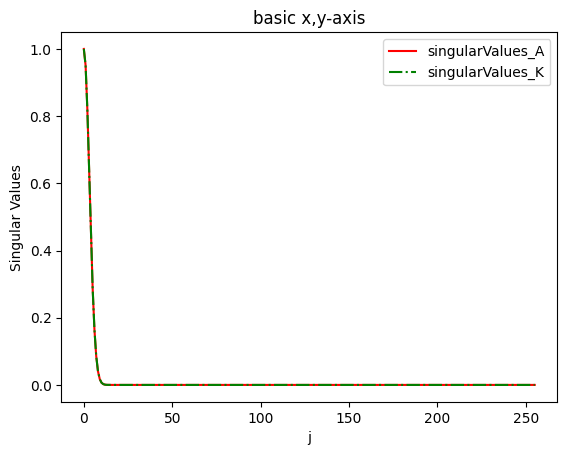

maxDiff:  4.1363146647928993e-16 
 --> which you can see better below


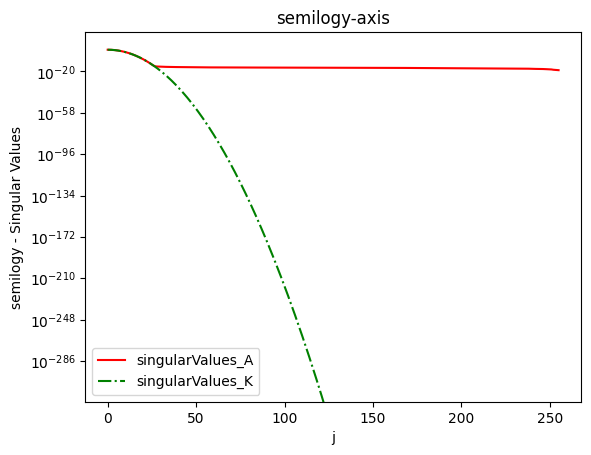

In [4]:
singularValues_A = np.linalg.svd(A,compute_uv=False)
mu = [np.exp(-T*j**2) for j in range(N)] # singularValues of K

plt.plot(singularValues_A,  color='red',linestyle='-', label='singularValues_A')
plt.plot(mu, color='green', linestyle='-.', label='singularValues_K')
plt.xlabel('j')
plt.ylabel('Singular Values')
plt.title('basic x,y-axis')
plt.legend()
plt.show()

maxDiff = np.max(np.abs(singularValues_A - mu))
print("maxDiff: ",maxDiff, "\n --> which you can see better below")

plt.semilogy(singularValues_A,  color='red',linestyle='-', label='singularValues_A')
plt.semilogy(mu, color='green', linestyle='-.', label='singularValues_K')
plt.xlabel('j')
plt.ylabel('semilogy - Singular Values')
plt.title('semilogy-axis')
plt.legend()    
plt.show()

C:\Users\ansch\AppData\Local\Temp\ipykernel_7604\3875934768.py:16: RuntimeWarning: divide by zero encountered in divide
  relativ_ydelta_mu = c_ydelta/mu
C:\Users\ansch\AppData\Local\Temp\ipykernel_7604\3875934768.py:16: RuntimeWarning: overflow encountered in divide
  relativ_ydelta_mu = c_ydelta/mu


[np.float64(1.0), np.float64(0.951229424500714), np.float64(0.8187307530779818), np.float64(0.6376281516217733), np.float64(0.44932896411722156), np.float64(0.2865047968601901), np.float64(0.16529888822158653), np.float64(0.0862935864993705), np.float64(0.04076220397836621), np.float64(0.017422374639493515), np.float64(0.006737946999085467), np.float64(0.0023578620064902307), np.float64(0.0007465858083766792), np.float64(0.0002139004153676611), np.float64(5.5451599432176945e-05), np.float64(1.300729765406762e-05), np.float64(2.7607725720371986e-06), np.float64(5.302061201824281e-07), np.float64(9.213600834566135e-08), np.float64(1.4487204867720514e-08), np.float64(2.061153622438558e-09), np.float64(2.6534241286428096e-10), np.float64(3.090818748408321e-11), np.float64(3.2576989934350907e-12), np.float64(3.1068402375434455e-13), np.float64(2.6810038677818034e-14), np.float64(2.0933724855193764e-15), np.float64(1.478993054892707e-16), np.float64(9.454886273886542e-18), np.float64(5.46911

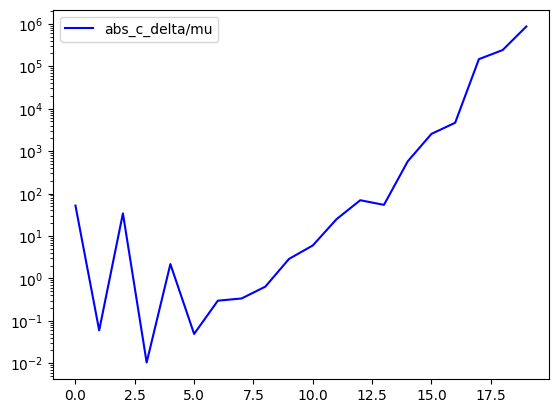

In [5]:
# Ex 1.c

np.random.seed(42)
d = np.random.randn(N)
d = d/np.linalg.norm(d) * 0.01 * np.linalg.norm(y_grid)
# print(np.round(d,3))

y_delta = Kx_grid + d    # Kx + d
# print(Kx_grid)print(y_delta[0:50])
# |(y_delta,y_j)|
c_ydelta = dct(y_delta, type=2, norm='ortho') # cosine coefficients+
abs_c_ydelta = np.abs(c_ydelta)

# print(c_ydelta[0:50])
# calc |(y_delta,y_j)|/mu_j
relativ_ydelta_mu = c_ydelta/mu
abs_relativ_ydelta_mu = np.abs(relativ_ydelta_mu)
print(mu[0:50])
# print(relativ_ydelta_mu)
# print(c_ydelta)
# plt.semilogy(mu[0:50],                  color='red',label='mu')
# plt.semilogy(abs_c_ydelta[0:50],            color='green',label='abs_c_ydelta')
plt.semilogy(abs_relativ_ydelta_mu[0:20],   color='blue',label='abs_c_delta/mu')
plt.legend()
# plt.xlim(0,50)
plt.show()

we cut at an index, where the functions starts to increase again $\rightarrow$ somewhere between 5 and 8 $\rightarrow$ so we only take the first few $\mu$  

In [21]:
a = 8

# normed Basisfunctions
x_j = lambda j,s: np.sqrt(2/N) * np.cos(j*s) if j!=0 else 1/np.sqrt(N)

x_alpha = lambda index, s: sum( relativ_ydelta_mu[i] * x_j(i,s) for i in range(index))
# x_alpha_array = np.zeros(N)
#
# for k in range(N):
#     x_alpha_array[k] = x_alpha(a,s_grid[k])
# # print(x_alpha _array)

# for a_index in [2,4,6,8,10,12]:
#     x_alpha_array = np.zeros(N)
#     for k in range(N):
#         x_alpha_array[k] = x_alpha(a_index,s_grid[k])
#     plt.plot(x_alpha_array,lw=1,label=f'alpha={a_index}')

# plt.plot(x_alpha_array,lw=1,label='x_alpha_array')
# plt.plot(x_grid,color='green',lw=1,label='x_grid')
# plt.legend()
# plt.show()

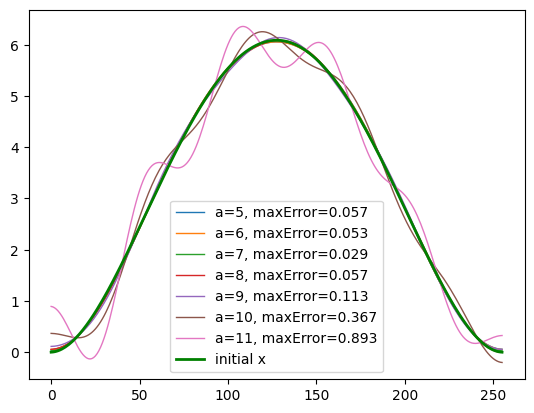

for alpha=5	-> MaxError of 0.057
for alpha=6	-> MaxError of 0.053
for alpha=7	-> MaxError of 0.029
for alpha=8	-> MaxError of 0.057
for alpha=9	-> MaxError of 0.113
for alpha=10	-> MaxError of 0.367
for alpha=11	-> MaxError of 0.893


In [22]:
Mstart=5
Mend=12
maxDiff = np.zeros(Mend-Mstart)
for a_index in range(Mstart,Mend):
    x_alpha_array = np.zeros(N)
    for k in range(N):
        x_alpha_array[k] = x_alpha(a_index,s_grid[k])
        maxDiff[a_index-Mstart] = np.max(np.abs(x_alpha_array - x_grid))
    plt.plot(x_alpha_array,lw=1,label=f'a={a_index}, maxError={round(maxDiff[a_index-Mstart],3)}')


# plt.plot(x_alpha_array,lw=1,label='x_alpha_array')
plt.plot(x_grid,color='green',lw=2,label='initial x')
plt.legend()
# plt.xlim(100,150)
# plt.ylim(4,8)
plt.show()

for i in range(Mstart,Mend):
    print(f"for alpha={i}\t-> MaxError of {round(maxDiff[i-Mstart],3)}")